# Classification

This notebook tunes multiple Classification Algorithms to classifier whether a set of values are LOS/NLOS, thereafter, the models accuracy and F1 scores are visualized to compare their performances.

## Objectives

1. Compute the hyperparameters via GridSearchCV.
2. Conduct further tuning to ensure that the best combination of hyperparameters are chosen.
3. Compare performance using Precision, Accuracy, F1-Score, Confusion Matrix


In [1]:
import numpy as np


data = np.load("../processed_data/classification_data.npz")

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

print("Unique classes:", np.unique(y_train))
print("Train class counts:", np.bincount(y_train.astype(int)))
print("Test class counts: ", np.bincount(y_test.astype(int)))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Unique classes: [0 1]
Train class counts: [16799 16800]
Test class counts:  [4200 4200]
Train shape: (33599, 102)
Test shape: (8400, 102)


## Classification Model Tuning

### Workflow for Both RandomForest and BoostedGradient
1. Initial Tuning with GridSearchCV
2. Individual Tuning with Validation Curves (To ensure optimal choice taken)

### Random Forest

In [ ]:
# Random Forest model selection using GridSearchCV


import numpy as np
import pandas as pd


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


print("X_train_classification shape:", X_train.shape)
print("X_test_classification shape :", X_test.shape)
print("y_train shape              :", y_train.shape)
print("y_test shape               :", y_test.shape)


# ---------------------------------------------------------------------------
# Define base Random Forest and hyperparameter grid
# ---------------------------------------------------------------------------
base_rf = RandomForestClassifier(
    n_estimators=150,          # manual baseline choice
    max_depth=20,              # manual baseline choice
    min_samples_split=5,       # manual baseline choice
    min_samples_leaf=2,        # manual baseline choice
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)


param_grid = {
    "n_estimators": [150, 200, 300],
    "max_depth": [8, 12, 16, 20, 24, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="f1",              # choose the model with best F1-score
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)


print("Running GridSearchCV over n_estimators, max_depth, min_samples_split, min_samples_leaf...")
grid.fit(X_test, y_train)


print("\nBest parameters (by F1-score on CV):")
print(grid.best_params_)
print("Best mean CV F1-score:", round(grid.best_score_, 4))


# ---------------------------------------------------------------------------
# Build a clear comparison table for all hyperparameter combinations
# ---------------------------------------------------------------------------
results = pd.DataFrame(grid.cv_results_)
cols_to_show = [
    "param_n_estimators",
    "param_max_depth",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1",
    "std_test_f1",
    "rank_test_f1"
]


comparison_table = (
    results[cols_to_show]
    .sort_values("rank_test_f1")
    .reset_index(drop=True)
)


print("\nGridSearchCV results (sorted by F1 rank, best = rank 1):")
print(comparison_table.to_string(index=True))


# Highlight the row corresponding to the chosen manual hyperparameters
target_n_estimators = 150
target_max_depth = 20
target_min_samples_split = 5
target_min_samples_leaf = 2
mask_target = (
    (results["param_n_estimators"] == target_n_estimators)
    & (results["param_max_depth"] == target_max_depth)
    & (results["param_min_samples_split"] == target_min_samples_split)
    & (results["param_min_samples_leaf"] == target_min_samples_leaf)
)


print("\nPerformance for chosen manual hyperparameters (n_estimators=150, max_depth=20, min_samples_split=5, min_samples_leaf=2):")
print(results.loc[mask_target, cols_to_show].to_string(index=False))


# ---------------------------------------------------------------------------
# Evaluate the best model on the held-out test set
# ---------------------------------------------------------------------------
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()


print("\nTest set performance for best hyperparameters:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))
print("F1       :", round(f1_score(y_test, y_pred_best), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))


print("\nConfusion Matrix (test set):")
print(cm)
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)


print("\nClassification Report (test set):")
print(classification_report(y_test, y_pred_best, target_names=["LOS", "NLOS"]))

X_train_classification shape: (33600, 102)
X_test_classification shape : (8400, 102)
y_train shape              : (33600,)
y_test shape               : (8400,)
Running GridSearchCV over n_estimators, max_depth, min_samples_split, min_samples_leaf...

Best parameters (by F1-score on CV):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best mean CV F1-score: 0.8779

GridSearchCV results (sorted by F1 rank, best = rank 1):
    param_n_estimators param_max_depth  mean_test_accuracy  std_test_accuracy  mean_test_f1  std_test_f1  rank_test_f1
0                  150            None            0.882083           0.003074      0.877930     0.003585             1
1                  200            None            0.881607           0.002938      0.877448     0.003345             2
2                  300            None            0.881488           0.002123      0.877387     0.002514             3
3                  300              20            0.881577  

Random Forest validation curve for n_estimators


F1 scores per n_estimators at max_depth=24:
 param_n_estimators  mean_train_f1  mean_val_f1
                150       0.995341     0.876572
                200       0.995664     0.876438
                300       0.995942     0.876781


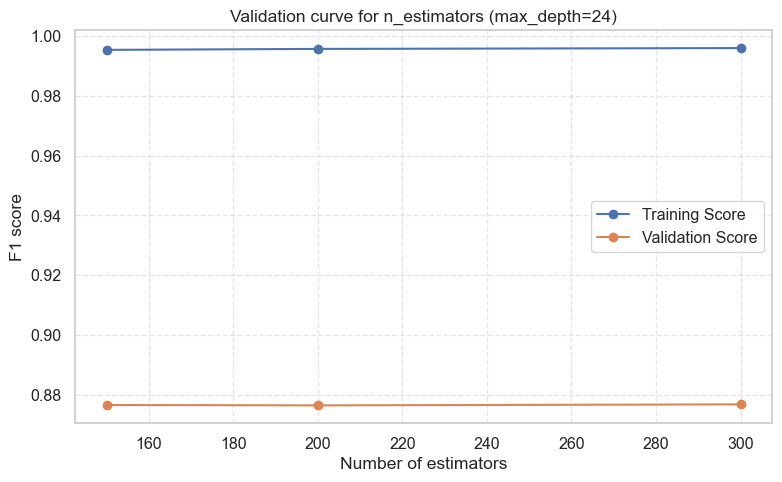

In [ ]:
# Validation curve for n_estimators (F1 score)
import matplotlib.pyplot as plt

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_df = results
except NameError:
    # fall back to grid.cv_results_ if results is not defined
    cv_results_df = pd.DataFrame(grid.cv_results_)

# Filter to max_depth = 24 so we only look at that depth
target_max_depth = 24
cv_results_df_md24 = cv_results_df[cv_results_df["param_max_depth"] == target_max_depth]

# Group by n_estimators at the chosen max_depth
summary_n = (
    cv_results_df_md24
    .groupby("param_n_estimators")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
    .sort_values("param_n_estimators")
)

print(f"\nF1 scores per n_estimators at max_depth={target_max_depth}:")
print(summary_n.to_string(index=False))

# Plot validation curve
plt.figure(figsize=(8, 5))
plt.plot(summary_n["param_n_estimators"], summary_n["mean_train_f1"], marker="o", label="Training Score")
plt.plot(summary_n["param_n_estimators"], summary_n["mean_val_f1"], marker="o", label="Validation Score")
plt.xlabel("Number of estimators")
plt.ylabel("F1 score")
plt.title(f"Validation curve for n_estimators (max_depth={target_max_depth})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest validation curve for max_depth


Random Forest max_depth tuning summary (n_estimators=150):
 max_depth  Train F1  Validation F1
        24    0.9953         0.8766
        20    0.9879         0.8763
        16    0.9646         0.8752
        12    0.9299         0.8735
         8    0.8868         0.8682


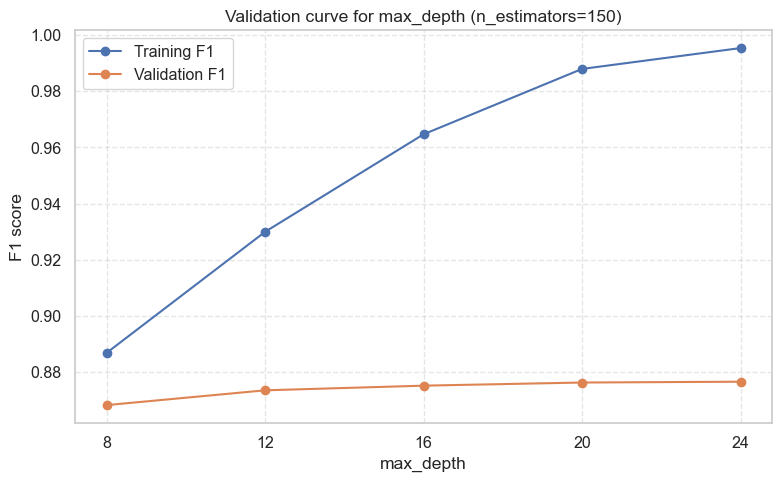

In [ ]:
# Validation curve for max_depth (F1 score)
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_md = results
except NameError:
    cv_results_md = pd.DataFrame(grid.cv_results_)

# Restrict to a fixed number of estimators
target_n_estimators = 150
cv_results_md_n150 = cv_results_md[cv_results_md["param_n_estimators"] == target_n_estimators]

# ---------------------------------------------------------------------------
# Table: average Train / Validation F1 for each max_depth at n_estimators = 150
# ---------------------------------------------------------------------------
summary_md = (
    cv_results_md_n150
    .groupby("param_max_depth")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
 )

summary_md_pretty = summary_md.rename(columns={
    "param_max_depth": "max_depth",
    "mean_train_f1": "Train F1",
    "mean_val_f1": "Validation F1",
})

# Sort by Validation F1 descending to see best depth first
summary_md_pretty = summary_md_pretty.sort_values("Validation F1", ascending=False).reset_index(drop=True)

print(f"\nRandom Forest max_depth tuning summary (n_estimators={target_n_estimators}):")
print(summary_md_pretty.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------------------------------------------------------------------
# Plot validation curve for max_depth
# ---------------------------------------------------------------------------
# Use positions on x-axis so we can include None as a label
x_pos = np.arange(len(summary_md))
train_f1_vals = summary_md["mean_train_f1"].values
val_f1_vals   = summary_md["mean_val_f1"].values
labels        = summary_md["param_max_depth"].astype(str).values

plt.figure(figsize=(8, 5))
plt.plot(x_pos, train_f1_vals, marker="o", label="Training F1")
plt.plot(x_pos, val_f1_vals, marker="o", label="Validation F1")
plt.xticks(x_pos, labels)
plt.xlabel("max_depth")
plt.ylabel("F1 score")
plt.title(f"Validation curve for max_depth (n_estimators={target_n_estimators})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest validation curve for min_samples_split


Random Forest min_samples_split tuning summary (max_depth=20, n_estimators=150):
 min_samples_split  Train F1  Validation F1
                 2    0.9905         0.8763
                 5    0.9854         0.8762


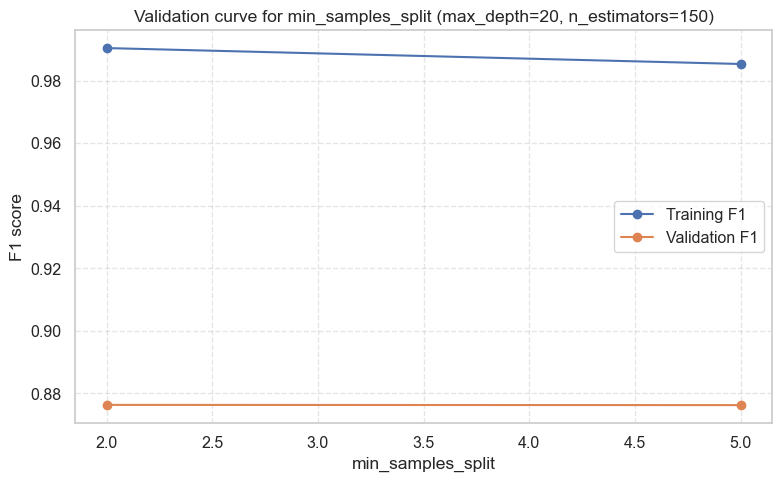

In [ ]:
# Validation curve for min_samples_split (F1 score)
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_split = results
except NameError:
    cv_results_split = pd.DataFrame(grid.cv_results_)

# If min_samples_split was not part of the grid, warn and skip
if "param_min_samples_split" not in cv_results_split.columns:
    raise KeyError("param_min_samples_split is not in cv_results_. Add min_samples_split to param_grid in Cell 5.")

# Restrict to max_depth = 20 and n_estimators = 150
target_max_depth = 20
target_n_estimators = 150
cv_results_split_sel = cv_results_split[(
    (cv_results_split["param_max_depth"] == target_max_depth)
    & (cv_results_split["param_n_estimators"] == target_n_estimators)
)]

# ---------------------------------------------------------------------------
# Table: average Train / Validation F1 for each min_samples_split at the chosen settings
# ---------------------------------------------------------------------------
summary_split = (
    cv_results_split_sel
    .groupby("param_min_samples_split")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
    .sort_values("param_min_samples_split")
)

summary_split_pretty = summary_split.rename(columns={
    "param_min_samples_split": "min_samples_split",
    "mean_train_f1": "Train F1",
    "mean_val_f1": "Validation F1",
})

print(f"\nRandom Forest min_samples_split tuning summary (max_depth={target_max_depth}, n_estimators={target_n_estimators}):")
print(summary_split_pretty.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------------------------------------------------------------------
# Plot validation curve for min_samples_split
# ---------------------------------------------------------------------------
x_vals_split = summary_split["param_min_samples_split"].values
train_f1_vals_split = summary_split["mean_train_f1"].values
val_f1_vals_split   = summary_split["mean_val_f1"].values

plt.figure(figsize=(8, 5))
plt.plot(x_vals_split, train_f1_vals_split, marker="o", label="Training F1")
plt.plot(x_vals_split, val_f1_vals_split, marker="o", label="Validation F1")
plt.xlabel("min_samples_split")
plt.ylabel("F1 score")
plt.title(f"Validation curve for min_samples_split (max_depth={target_max_depth}, n_estimators={target_n_estimators})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest validation curve for min_samples_leaf


Random Forest min_samples_leaf tuning summary (max_depth=20, n_estimators=150, min_samples_split=2):
 min_samples_leaf  Train F1  Validation F1
                1    0.9948         0.8762
                2    0.9861         0.8765


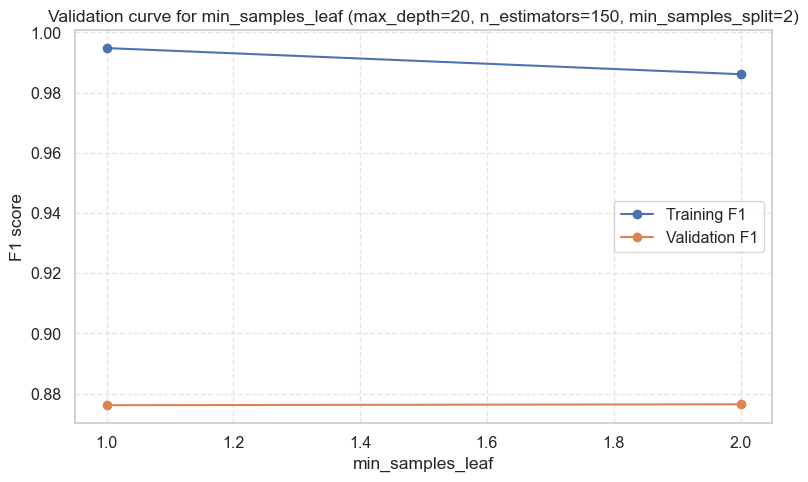

In [ ]:
# Validation curve for min_samples_leaf (F1 score)
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have the cv_results_ as a DataFrame
try:
    cv_results_leaf = results
except NameError:
    cv_results_leaf = pd.DataFrame(grid.cv_results_)

# If min_samples_leaf was not part of the grid, warn and skip
if "param_min_samples_leaf" not in cv_results_leaf.columns:
    raise KeyError("param_min_samples_leaf is not in cv_results_. Add min_samples_leaf to param_grid in Cell 5.")

# Restrict to max_depth = 20, n_estimators = 150, and min_samples_split = 2
target_max_depth = 20
target_n_estimators = 150
target_min_samples_split = 2
cv_results_leaf_sel = cv_results_leaf[(
    (cv_results_leaf["param_max_depth"] == target_max_depth)
    & (cv_results_leaf["param_n_estimators"] == target_n_estimators)
    & (cv_results_leaf["param_min_samples_split"] == target_min_samples_split)
)]

# ---------------------------------------------------------------------------
# Table: average Train / Validation F1 for each min_samples_leaf at the chosen settings
# ---------------------------------------------------------------------------
summary_leaf = (
    cv_results_leaf_sel
    .groupby("param_min_samples_leaf")
    .agg(
        mean_train_f1=("mean_train_f1", "mean"),
        mean_val_f1=("mean_test_f1", "mean"),
    )
    .reset_index()
    .sort_values("param_min_samples_leaf")
)

summary_leaf_pretty = summary_leaf.rename(columns={
    "param_min_samples_leaf": "min_samples_leaf",
    "mean_train_f1": "Train F1",
    "mean_val_f1": "Validation F1",
})

print(f"\nRandom Forest min_samples_leaf tuning summary (max_depth={target_max_depth}, n_estimators={target_n_estimators}, min_samples_split={target_min_samples_split}):")
print(summary_leaf_pretty.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ---------------------------------------------------------------------------
# Plot validation curve for min_samples_leaf
# ---------------------------------------------------------------------------
x_vals_leaf = summary_leaf["param_min_samples_leaf"].values
train_f1_vals_leaf = summary_leaf["mean_train_f1"].values
val_f1_vals_leaf   = summary_leaf["mean_val_f1"].values

plt.figure(figsize=(8, 5))
plt.plot(x_vals_leaf, train_f1_vals_leaf, marker="o", label="Training F1")
plt.plot(x_vals_leaf, val_f1_vals_leaf, marker="o", label="Validation F1")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1 score")
plt.title(f"Validation curve for min_samples_leaf (max_depth={target_max_depth}, n_estimators={target_n_estimators}, min_samples_split={target_min_samples_split})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Boosted Gradient

### IF ERROR WITH MISSING XGBOOST AND CATBOOST RUN BOTTOM CELL

In [ ]:
%pip install xgboost
%pip install catboost

In [2]:

import time
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, validation_curve, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_test_pred),
        "Training Time (s)": end_time - start_time
    }

    print("\n" + "="*60)
    print(model_name)
    print("="*60)
    print("Train Accuracy :", round(results["Train Accuracy"], 4))
    print("Test Accuracy  :", round(results["Test Accuracy"], 4))
    print("Train F1       :", round(results["Train F1"], 4))
    print("Test F1        :", round(results["Test F1"], 4))
    print("Precision      :", round(results["Test Precision"], 4))
    print("Recall         :", round(results["Test Recall"], 4))
    print("Training Time  :", round(results["Training Time (s)"], 4), "seconds")
    print("Confusion Matrix:\n", results["Confusion Matrix"])
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_test_pred))

    return results

def plot_validation_curve(model, X, y, param_name, param_range, cv=3, scoring='f1', title=None):
    train_scores, valid_scores = validation_curve(
        model,
        X,
        y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    valid_mean = np.mean(valid_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_mean, marker='o', label='Training F1')
    plt.plot(param_range, valid_mean, marker='s', label='Validation F1')
    plt.xlabel(param_name)
    plt.ylabel('F1 Score')
    plt.title(title if title else f'Validation Curve for {param_name}')
    plt.legend()
    plt.grid(True)
    plt.show()

    for i in range(len(param_range)):
        print(f"{param_name} = {param_range[i]} | Train F1 = {train_mean[i]:.4f} | Validation F1 = {valid_mean[i]:.4f}")

    best_index = np.argmax(valid_mean)
    print(f"\nBest {param_name}: {param_range[best_index]}")
    print(f"Best Validation F1: {valid_mean[best_index]:.4f}")

    return train_mean, valid_mean

### Initial Tuning with GridSearchCV

In [4]:
gb_base = GradientBoostingClassifier(learning_rate=0.01, random_state=42)

param_grid_gb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 10, 15]
}

grid_search_gb = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

grid_search_gb.fit(X_train, y_train)

best_model = grid_search_gb.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", grid_search_gb.best_params_)
print("Best CV F1:", grid_search_gb.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nReport:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params: {'max_depth': 10, 'n_estimators': 200}
Best CV F1: 0.8819316602439559
Test accuracy: 0.8840476190476191

Confusion matrix:
[[3858  342]
 [ 632 3568]]

Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4200
           1       0.91      0.85      0.88      4200

    accuracy                           0.88      8400
   macro avg       0.89      0.88      0.88      8400
weighted avg       0.89      0.88      0.88      8400



### Individual Tuning of n_estimators, learning_rate and max_depth

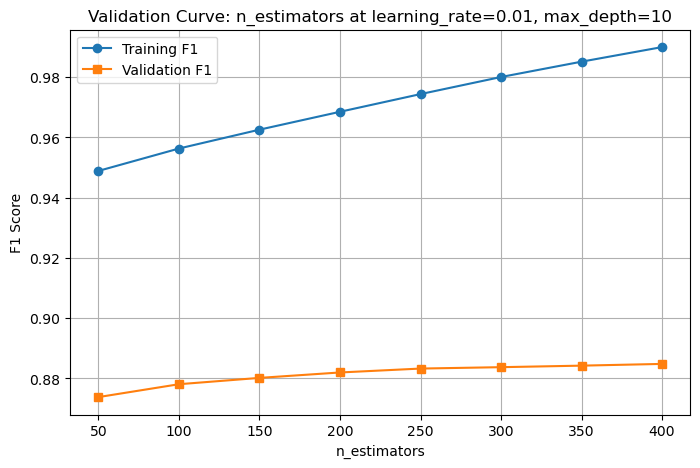

n_estimators = 50 | Train F1 = 0.9489 | Validation F1 = 0.8738
n_estimators = 100 | Train F1 = 0.9563 | Validation F1 = 0.8780
n_estimators = 150 | Train F1 = 0.9626 | Validation F1 = 0.8801
n_estimators = 200 | Train F1 = 0.9685 | Validation F1 = 0.8819
n_estimators = 250 | Train F1 = 0.9744 | Validation F1 = 0.8832
n_estimators = 300 | Train F1 = 0.9800 | Validation F1 = 0.8837
n_estimators = 350 | Train F1 = 0.9851 | Validation F1 = 0.8842
n_estimators = 400 | Train F1 = 0.9900 | Validation F1 = 0.8848

Best n_estimators: 400
Best Validation F1: 0.8848


(array([0.94885518, 0.95629028, 0.96255098, 0.96848709, 0.97436198,
        0.98003424, 0.98512605, 0.98996848]),
 array([0.87375968, 0.8780326 , 0.88013181, 0.88193166, 0.8832285 ,
        0.8836892 , 0.88419754, 0.88477308]))

In [5]:
param_range_n1 = [50, 100, 150, 200, 250, 300, 350, 400]

model_n1 = GradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=10,
    random_state=42
)

plot_validation_curve(
    model_n1,
    X_train,
    y_train,
    param_name="n_estimators",
    param_range=param_range_n1,
    cv=3,
    scoring="f1",
    title="Validation Curve: n_estimators at learning_rate=0.01, max_depth=10"
)

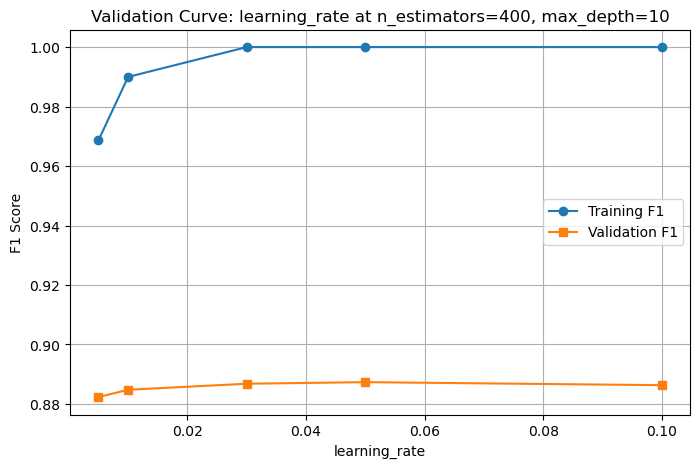

learning_rate = 0.005 | Train F1 = 0.9686 | Validation F1 = 0.8823
learning_rate = 0.01 | Train F1 = 0.9900 | Validation F1 = 0.8848
learning_rate = 0.03 | Train F1 = 1.0000 | Validation F1 = 0.8868
learning_rate = 0.05 | Train F1 = 1.0000 | Validation F1 = 0.8873
learning_rate = 0.1 | Train F1 = 1.0000 | Validation F1 = 0.8863

Best learning_rate: 0.05
Best Validation F1: 0.8873


(array([0.96864137, 0.98996848, 1.        , 1.        , 1.        ]),
 array([0.88230536, 0.88477308, 0.88679696, 0.88732466, 0.88630544]))

In [7]:
param_range_lr = [0.005, 0.01, 0.03, 0.05, 0.1]

model_lr = GradientBoostingClassifier(
    n_estimators=400,
    max_depth=10,
    random_state=42
)

plot_validation_curve(
    model_lr,
    X_train,
    y_train,
    param_name="learning_rate",
    param_range=param_range_lr,
    cv=3,
    scoring="f1",
    title="Validation Curve: learning_rate at n_estimators=400, max_depth=10"
)

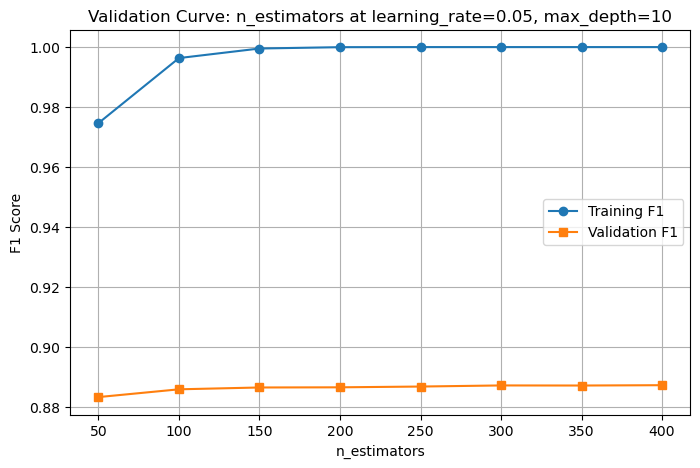

n_estimators = 50 | Train F1 = 0.9747 | Validation F1 = 0.8834
n_estimators = 100 | Train F1 = 0.9963 | Validation F1 = 0.8860
n_estimators = 150 | Train F1 = 0.9995 | Validation F1 = 0.8866
n_estimators = 200 | Train F1 = 1.0000 | Validation F1 = 0.8866
n_estimators = 250 | Train F1 = 1.0000 | Validation F1 = 0.8869
n_estimators = 300 | Train F1 = 1.0000 | Validation F1 = 0.8872
n_estimators = 350 | Train F1 = 1.0000 | Validation F1 = 0.8872
n_estimators = 400 | Train F1 = 1.0000 | Validation F1 = 0.8873

Best n_estimators: 400
Best Validation F1: 0.8873


(array([0.97466048, 0.99634018, 0.99952407, 0.99997024, 1.        ,
        1.        , 1.        , 1.        ]),
 array([0.8833635 , 0.88595347, 0.88656194, 0.88661737, 0.88687539,
        0.88724373, 0.88721496, 0.88732466]))

In [8]:
param_range_n2 = [50, 100, 150, 200, 250, 300, 350, 400]

model_n2 = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)

plot_validation_curve(
    model_n2,
    X_train,
    y_train,
    param_name="n_estimators",
    param_range=param_range_n2,
    cv=3,
    scoring="f1",
    title="Validation Curve: n_estimators at learning_rate=0.05, max_depth=10"
)

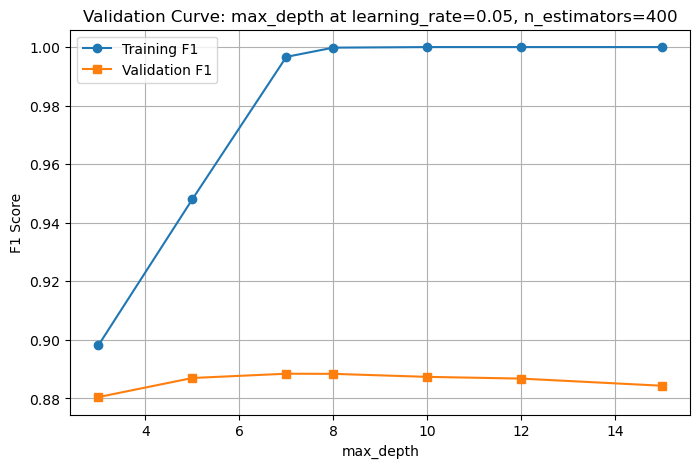

max_depth = 3 | Train F1 = 0.8981 | Validation F1 = 0.8804
max_depth = 5 | Train F1 = 0.9480 | Validation F1 = 0.8869
max_depth = 7 | Train F1 = 0.9967 | Validation F1 = 0.8884
max_depth = 8 | Train F1 = 0.9998 | Validation F1 = 0.8884
max_depth = 10 | Train F1 = 1.0000 | Validation F1 = 0.8873
max_depth = 12 | Train F1 = 1.0000 | Validation F1 = 0.8867
max_depth = 15 | Train F1 = 1.0000 | Validation F1 = 0.8843

Best max_depth: 7
Best Validation F1: 0.8884


(array([0.89812663, 0.9480359 , 0.9966593 , 0.99980659, 1.        ,
        1.        , 1.        ]),
 array([0.88041628, 0.88693922, 0.88839894, 0.8883506 , 0.88732466,
        0.88673267, 0.88428896]))

In [10]:
param_range_depth = [3, 5, 7, 8, 10, 12, 15]

model_depth = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=400,
    random_state=42
)

plot_validation_curve(
    model_depth,
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range_depth,
    cv=3,
    scoring="f1",
    title="Validation Curve: max_depth at learning_rate=0.05, n_estimators=400"
)

### Comparison of Base Model to Tuned Model

In [11]:
base_gb = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=200,
    max_depth=10,
    random_state=42
)

tuned_gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    random_state=42
)

base_gb_results = evaluate_model(
    base_gb,
    X_train, X_test, y_train, y_test,
    model_name="Based GradientBoosting"
)

tuned_gb_results = evaluate_model(
    tuned_gb,
    X_train, X_test, y_train, y_test,
    model_name="Tuned GradientBoosting"
)


Based GradientBoosting
Train Accuracy : 0.9614
Test Accuracy  : 0.884
Train F1       : 0.9604
Test F1        : 0.8799
Precision      : 0.9125
Recall         : 0.8495
Training Time  : 898.5174 seconds
Confusion Matrix:
 [[3858  342]
 [ 632 3568]]

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4200
           1       0.91      0.85      0.88      4200

    accuracy                           0.88      8400
   macro avg       0.89      0.88      0.88      8400
weighted avg       0.89      0.88      0.88      8400


Tuned GradientBoosting
Train Accuracy : 0.9876
Test Accuracy  : 0.8918
Train F1       : 0.9877
Test F1        : 0.8882
Precision      : 0.9184
Recall         : 0.86
Training Time  : 1339.5653 seconds
Confusion Matrix:
 [[3879  321]
 [ 588 3612]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      4200
           1       0

### Individual Tuning of subsample, min_samples_split and min_samples_leaf

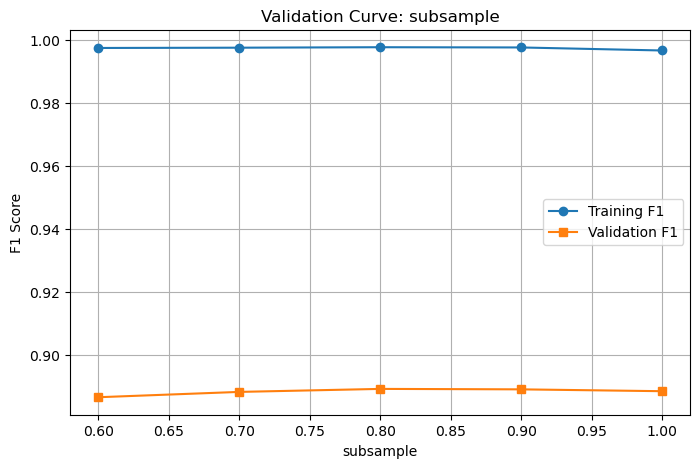

subsample = 0.6 | Train F1 = 0.9975 | Validation F1 = 0.8865
subsample = 0.7 | Train F1 = 0.9976 | Validation F1 = 0.8882
subsample = 0.8 | Train F1 = 0.9977 | Validation F1 = 0.8891
subsample = 0.9 | Train F1 = 0.9976 | Validation F1 = 0.8890
subsample = 1.0 | Train F1 = 0.9967 | Validation F1 = 0.8884

Best subsample: 0.8
Best Validation F1: 0.8891


(array([0.99746153, 0.99755015, 0.99769817, 0.99762399, 0.9966593 ]),
 array([0.88648506, 0.88817548, 0.88912926, 0.88898533, 0.88839894]))

In [12]:
param_range_subsample = [0.6, 0.7, 0.8, 0.9, 1.0]

model_subsample = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    random_state=42
)

plot_validation_curve(
    model_subsample,
    X_train,
    y_train,
    param_name="subsample",
    param_range=param_range_subsample,
    cv=3,
    scoring="f1",
    title="Validation Curve: subsample"
)

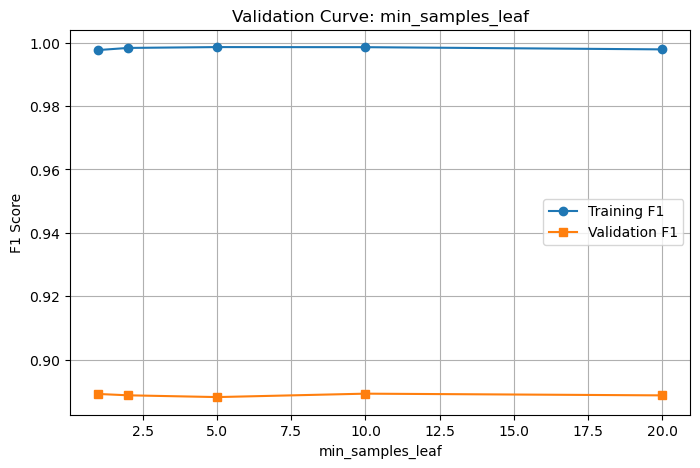

min_samples_leaf = 1 | Train F1 = 0.9977 | Validation F1 = 0.8891
min_samples_leaf = 2 | Train F1 = 0.9984 | Validation F1 = 0.8887
min_samples_leaf = 5 | Train F1 = 0.9986 | Validation F1 = 0.8881
min_samples_leaf = 10 | Train F1 = 0.9986 | Validation F1 = 0.8892
min_samples_leaf = 20 | Train F1 = 0.9979 | Validation F1 = 0.8887

Best min_samples_leaf: 10
Best Validation F1: 0.8892


(array([0.99769817, 0.99836568, 0.99863275, 0.99860299, 0.99790602]),
 array([0.88912926, 0.88870796, 0.88814839, 0.88922815, 0.88868732]))

In [15]:
param_range_leaf = [1, 2, 5, 10, 20]

model_leaf = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=,
    subsample=0.8,
    random_state=42
)

plot_validation_curve(
    model_leaf,
    X_train,
    y_train,
    param_name="min_samples_leaf",
    param_range=param_range_leaf,
    cv=3,
    scoring="f1",
    title="Validation Curve: min_samples_leaf"
)

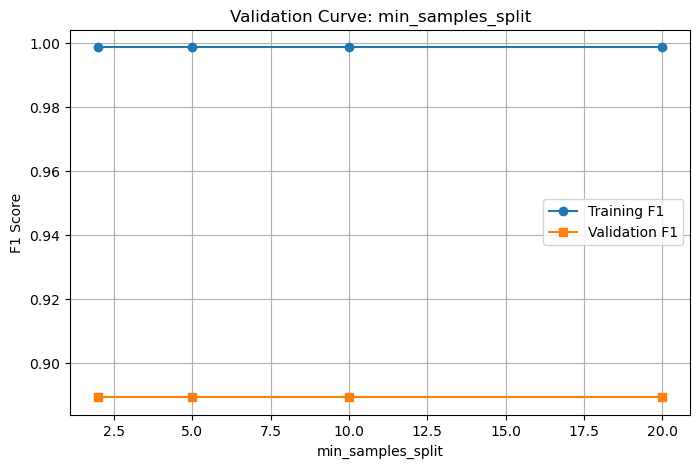

min_samples_split = 2 | Train F1 = 0.9986 | Validation F1 = 0.8892
min_samples_split = 5 | Train F1 = 0.9986 | Validation F1 = 0.8892
min_samples_split = 10 | Train F1 = 0.9986 | Validation F1 = 0.8892
min_samples_split = 20 | Train F1 = 0.9986 | Validation F1 = 0.8892

Best min_samples_split: 2
Best Validation F1: 0.8892


(array([0.99860299, 0.99860299, 0.99860299, 0.99860299]),
 array([0.88922815, 0.88922815, 0.88922815, 0.88922815]))

In [16]:
param_range_split = [2, 5, 10, 20]

model_split = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)

plot_validation_curve(
    model_split,
    X_train,
    y_train,
    param_name="min_samples_split",
    param_range=param_range_split,
    cv=3,
    scoring="f1",
    title="Validation Curve: min_samples_split"
)

### Tuned vs Further Tuned

In [21]:
further_tuned_gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    subsample=0.8,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

further_tuned_gb_results = evaluate_model(
    further_tuned_gb,
    X_train, X_test, y_train, y_test,
    model_name="Further Tuned GradientBoosting"
)


Further Tuned GradientBoosting
Train Accuracy : 0.9935
Test Accuracy  : 0.8914
Train F1       : 0.9935
Test F1        : 0.8879
Precision      : 0.9177
Recall         : 0.86
Training Time  : 1086.3738 seconds
Confusion Matrix:
 [[3876  324]
 [ 588 3612]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      4200
           1       0.92      0.86      0.89      4200

    accuracy                           0.89      8400
   macro avg       0.89      0.89      0.89      8400
weighted avg       0.89      0.89      0.89      8400



### Comparisons with other Boosted Gradient Models

In [24]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=7,
    max_iter=400,
    random_state=42
)

hgb_results = evaluate_model(
    hgb_model,
    X_train, X_test, y_train, y_test,
    model_name="HistGradientBoosting"
)

xgb_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_results = evaluate_model(
    xgb_model,
    X_train, X_test, y_train, y_test,
    model_name="XGBoost"
)

cat_model = CatBoostClassifier(
    learning_rate=0.05,
    iterations=400,
    depth=7,
    verbose=0,
    random_state=42
)

cat_results = evaluate_model(
    cat_model,
    X_train, X_test, y_train, y_test,
    model_name="CatBoost"
)


HistGradientBoosting
Train Accuracy : 0.9212
Test Accuracy  : 0.889
Train F1       : 0.9192
Test F1        : 0.8852
Precision      : 0.9168
Recall         : 0.8557
Training Time  : 2.997 seconds
Confusion Matrix:
 [[3874  326]
 [ 606 3594]]

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4200
           1       0.92      0.86      0.89      4200

    accuracy                           0.89      8400
   macro avg       0.89      0.89      0.89      8400
weighted avg       0.89      0.89      0.89      8400



C:\Users\isaac\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:10:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Train Accuracy : 0.9781
Test Accuracy  : 0.892
Train F1       : 0.978
Test F1        : 0.8887
Precision      : 0.9172
Recall         : 0.8619
Training Time  : 5.7103 seconds
Confusion Matrix:
 [[3873  327]
 [ 580 3620]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      4200
           1       0.92      0.86      0.89      4200

    accuracy                           0.89      8400
   macro avg       0.89      0.89      0.89      8400
weighted avg       0.89      0.89      0.89      8400


CatBoost
Train Accuracy : 0.9294
Test Accuracy  : 0.8901
Train F1       : 0.928
Test F1        : 0.8865
Precision      : 0.9166
Recall         : 0.8583
Training Time  : 11.2156 seconds
Confusion Matrix:
 [[3872  328]
 [ 595 3605]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.92      0.89      4200
           1       0.92      0.86      0.89      4200

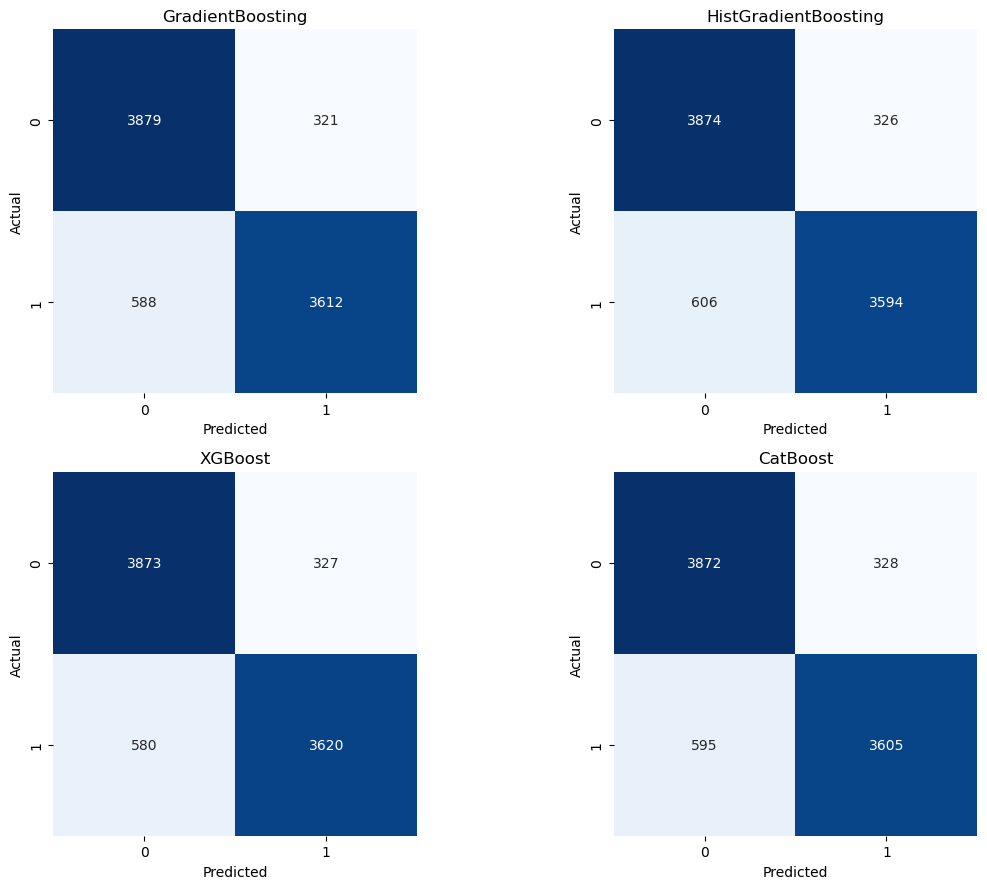

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_gb = [[3879, 321],[588, 3612]]
cm_hgb = [[3874,  326],[606, 3594]]
cm_xgb = [[3873,  327],[ 580,3620]]
cm_cat = [[3872, 328], [595, 3605]]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

models = [
    ("GradientBoosting", cm_gb),
    ("HistGradientBoosting", cm_hgb),
    ("XGBoost", cm_xgb),
    ("CatBoost", cm_cat)
]

for ax, (title, cm) in zip(axes.flatten(), models):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        xticklabels=[0, 1],
        yticklabels=[0, 1],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Random Forest vs XGBoost

Training XG Boosting...


C:\Users\isaac\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:30:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Random Forest...
Training Stacking Model...
MODEL: XG Boosting
Accuracy : 0.892
F1       : 0.8887
Precision: 0.9172
Recall   : 0.8619

Confusion Matrix:
[[3873  327]
 [ 580 3620]]

Breakdown
TN: 3873
FP: 327
FN: 580
TP: 3620

Classification Report:
              precision    recall  f1-score   support

         LOS       0.87      0.92      0.90      4200
        NLOS       0.92      0.86      0.89      4200

    accuracy                           0.89      8400
   macro avg       0.89      0.89      0.89      8400
weighted avg       0.89      0.89      0.89      8400

MODEL: Random Forest
Accuracy : 0.8813
F1       : 0.8769
Precision: 0.9107
Recall   : 0.8455

Confusion Matrix:
[[3852  348]
 [ 649 3551]]

Breakdown
TN: 3852
FP: 348
FN: 649
TP: 3551

Classification Report:
              precision    recall  f1-score   support

         LOS       0.86      0.92      0.89      4200
        NLOS       0.91      0.85      0.88      4200

    accuracy                           0.88

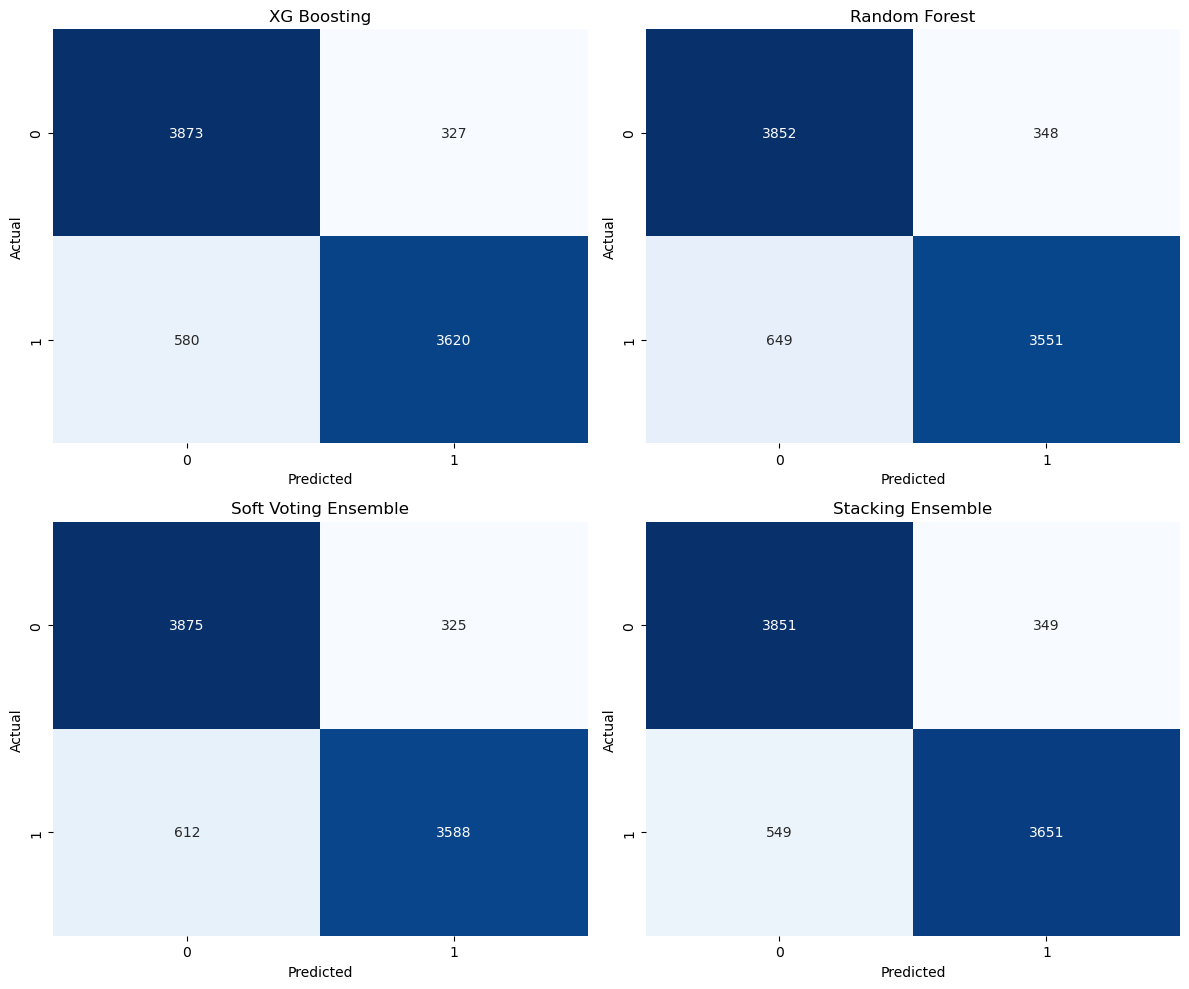

In [30]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

xgb_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=24,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

stack_model = StackingClassifier(
    estimators=[
        ("gb", xgb_model),
        ("rf", rf_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",   # use probabilities from base models
    cv=5,
    n_jobs=-1
)

print("Training XG Boosting...")
xgb_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training Stacking Model...")
stack_model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
xgb_pred = xgb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
stack_pred = stack_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# Combined prediction
# Soft voting
# -----------------------------
combined_prob = (xgb_prob + rf_prob) / 2
combined_pred = (combined_prob >= 0.5).astype(int)

# -----------------------------
# Helper function
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("=" * 70)
    print(f"MODEL: {name}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("F1       :", round(f1_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nBreakdown")
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["LOS", "NLOS"]))

    return cm

# -----------------------------
# Evaluate each model
# -----------------------------
cm_xgb = evaluate_model("XG Boosting", y_test, xgb_pred)
cm_rf = evaluate_model("Random Forest", y_test, rf_pred)
cm_combined = evaluate_model("Combined Ensemble (Soft Voting)", y_test, combined_pred)
cm_stack = evaluate_model("Stacking Ensemble", y_test, stack_pred)

# -----------------------------
# Optional: print all matrices neatly
# -----------------------------
print("=" * 70)
print("SUMMARY OF CONFUSION MATRICES")

print("\nXG Boosting Confusion Matrix")
print(cm_gb)

print("\nRandom Forest Confusion Matrix")
print(cm_rf)

print("\nCombined Ensemble Confusion Matrix")
print(cm_combined)

print("\nStacking Ensemble Confusion Matrix")
print(cm_stack)

# -----------------------------
# Plot heatmaps
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

matrices = [cm_xgb, cm_rf, cm_combined, cm_stack]
titles = [
    "XG Boosting",
    "Random Forest",
    "Soft Voting Ensemble",
    "Stacking Ensemble"
]

for ax, cm, title in zip(axes.flat, matrices, titles):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [32]:
from sklearn.ensemble import VotingClassifier

xgb_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=24,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

vote_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model)
    ],
    voting="soft",
    n_jobs=-1
)

stack_model = StackingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

# -----------------------------
# Helper function: Test-set evaluation
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("=" * 70)
    print(f"MODEL: {name}")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("F1       :", round(f1_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nBreakdown")
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["LOS", "NLOS"]))

    return cm

# -----------------------------
# Helper function: Cross-validation
# -----------------------------
def cross_validate_model(name, model, X, y, cv=3):
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1)

    print("=" * 70)
    print(f"CROSS-VALIDATION: {name}")
    print("F1 scores:", np.round(scores, 4))
    print("Mean F1  :", round(scores.mean(), 4))
    print("Std F1   :", round(scores.std(), 4))

    return scores

from sklearn.model_selection import cross_val_score
import numpy as np

def cross_validate_model(name, model, X, y, cv=3):
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1", n_jobs=-1)

    print("=" * 70)
    print(f"{name}")
    print("F1 scores:", np.round(scores, 4))
    print("Mean F1  :", round(scores.mean(), 4))
    print("Std F1   :", round(scores.std(), 4))

    return scores


# -----------------------------
# Run cross-validation
# -----------------------------
cv_xgb = cross_validate_model("XGBoost", xgb_model, X_train, y_train)
cv_rf = cross_validate_model("Random Forest", rf_model, X_train, y_train)
cv_vote = cross_validate_model("Soft Voting Ensemble", vote_model, X_train, y_train)
cv_stack = cross_validate_model("Stacking Ensemble", stack_model, X_train, y_train)

print("\n" + "=" * 70)
print("SUMMARY OF CROSS-VALIDATION RESULTS")

print(f"XGBoost              : {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}")
print(f"Random Forest        : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"Soft Voting Ensemble : {cv_vote.mean():.4f} ± {cv_vote.std():.4f}")
print(f"Stacking Ensemble    : {cv_stack.mean():.4f} ± {cv_stack.std():.4f}")

XGBoost
F1 scores: [0.8897 0.8907 0.8885]
Mean F1  : 0.8896
Std F1   : 0.0009
Random Forest
F1 scores: [0.8787 0.874  0.8734]
Mean F1  : 0.8754
Std F1   : 0.0024
Soft Voting Ensemble
F1 scores: [0.8878 0.8852 0.8855]
Mean F1  : 0.8862
Std F1   : 0.0011
Stacking Ensemble
F1 scores: [0.8914 0.8907 0.8883]
Mean F1  : 0.8902
Std F1   : 0.0013

SUMMARY OF CROSS-VALIDATION RESULTS
XGBoost              : 0.8896 ± 0.0009
Random Forest        : 0.8754 ± 0.0024
Soft Voting Ensemble : 0.8862 ± 0.0011
Stacking Ensemble    : 0.8902 ± 0.0013


In [37]:

def measure_avg_latency(model, X, runs=50):
    times = []

    for _ in range(runs):
        start = time.perf_counter()
        model.predict(X)
        end = time.perf_counter()
        times.append(end - start)

    times = np.array(times)

    total_avg = times.mean()                  # total batch time
    per_sample = total_avg / len(X)           # per sample

    return total_avg, per_sample

xgb_model.fit(X_train, y_train)
xgb_total, xgb_per_sample = measure_avg_latency(xgb_model, X_test)

stack_model.fit(X_train, y_train)
stack_total, stack_per_sample = measure_avg_latency(stack_model, X_test)

print("=" * 60)
print("INFERENCE TIME COMPARISON")
print("=" * 60)

print(f"XGBoost")
print(f"Total Time (batch): {xgb_total:.6f} s")
print(f"Time per sample   : {xgb_per_sample:.8f} s")

print("\nStacking Ensemble")
print(f"Total Time (batch): {stack_total:.6f} s")
print(f"Time per sample   : {stack_per_sample:.8f} s")

print("\n--- In milliseconds ---")

print(f"XGBoost per sample : {xgb_per_sample * 1000:.4f} ms")
print(f"Stacking per sample: {stack_per_sample * 1000:.4f} ms")

C:\Users\isaac\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:59:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


INFERENCE TIME COMPARISON
XGBoost
Total Time (batch): 0.009947 s
Time per sample   : 0.00000118 s

Stacking Ensemble
Total Time (batch): 0.072749 s
Time per sample   : 0.00000866 s

--- In milliseconds ---
XGBoost per sample : 0.0012 ms
Stacking per sample: 0.0087 ms


### Final Model

We chose a stacked model of both the XGBoost and Random Forest Classifiers as it had the least False Negatives and the highest F1-Score

Export model out for usage

In [39]:
import joblib

xgb_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=400,
    max_depth=7,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=24,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# Stacking model
stack_model = StackingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

# Fit
stack_model.fit(X_train, y_train)

# Save
joblib.dump(stack_model, "classifier_model.pkl")

['classifier_model.pkl']